# Harris Hawks Optimization (HHO) — Corrected Implementation

Fixes applied from algorithmic evaluation:

1. **E0 range**: confirmed `2*random.random()-1` → correct `[-1, 1)`
2. **Exploration q<0.5 branch**: now uses rabbit-energy-guided perch (attraction to prey region) instead of pure self-mutation
3. **Exploitation r<0.5 branches**: Lévy flight now drives the rapid-dive jump (`Y = X_rabbit − E·|X_rabbit − X[i]| + L·levy()`), adapted discretely
4. **W term**: greedy fallback now includes a Lévy-weighted alternative candidate Z in both r<0.5 branches
5. **Fitness normalization**: each term divided by its expected range so MW, donors, acceptors contribute equally
6. **Atom-level mutation**: operates on RDKit `Mol` objects (atom swap, bond edit, fragment add/remove) then canonicalizes — far higher valid-SMILES rate than character-level edits
7. **Fitness cache**: invalid SMILES also cached; initial population evaluated once before the loop

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from typing import Callable, Tuple, List, Optional


def levy_flight(dim: int) -> np.ndarray:
    """Lévy flight step vector (Mantegna algorithm, β=1.5)."""
    beta = 1.5
    sigma = (
        math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.abs(v) ** (1 / beta)


def levy_scalar() -> float:
    """Single Lévy step magnitude (used to scale discrete jumps)."""
    return float(abs(levy_flight(1)[0]))

iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
iteration: 5
iteration: 6


[17:09:43] non-ring atom 2 marked aromatic
[17:09:43] non-ring atom 2 marked aromatic
[17:09:43] non-ring atom 3 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 0 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] non-ring atom 1 marked aromatic
[17:09:43] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7
[17:09:43] non-ring atom 2 marked aromatic
[17:09:43] non-ring atom 3 marked aromatic
[17:09:43] non-ring atom 3 marked ar

iteration: 7
iteration: 8
iteration: 9
iteration: 10
iteration: 11
iteration: 12
iteration: 13
iteration: 14


[17:09:44] Explicit valence for atom # 14 Cl, 3, is greater than permitted
[17:09:44] Explicit valence for atom # 10 F, 3, is greater than permitted
[17:09:44] Explicit valence for atom # 11 Cl, 3, is greater than permitted
[17:09:44] non-ring atom 2 marked aromatic
[17:09:44] Can't kekulize mol.  Unkekulized atoms: 2 4 5 7 8
[17:09:44] non-ring atom 2 marked aromatic
[17:09:44] non-ring atom 8 marked aromatic
[17:09:44] non-ring atom 9 marked aromatic
[17:09:44] Explicit valence for atom # 3 F, 4, is greater than permitted
[17:09:44] Can't kekulize mol.  Unkekulized atoms: 3 4 5 8 9
[17:09:44] non-ring atom 2 marked aromatic
[17:09:44] non-ring atom 2 marked aromatic
[17:09:44] Explicit valence for atom # 4 Cl, 3, is greater than permitted
[17:09:44] Explicit valence for atom # 2 F, 4, is greater than permitted
[17:09:44] Explicit valence for atom # 15 F, 3, is greater than permitted
[17:09:44] non-ring atom 9 marked aromatic
[17:09:44] non-ring atom 9 marked aromatic
[17:09:44] Can't

iteration: 15
iteration: 16
iteration: 17
iteration: 18
iteration: 19
iteration: 20
iteration: 21
iteration: 22
iteration: 23
iteration: 24


...

iteration: 25
iteration: 26
iteration: 27
iteration: 28
iteration: 29
iteration: 30
iteration: 31
iteration: 32
iteration: 33
iteration: 34
iteration: 35


[17:09:45] non-ring atom 9 marked aromatic
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 14 15
[17:09:45] Explicit valence for atom # 3 O, 3, is greater than permitted
[17:09:45] Explicit valence for atom # 4 Cl, 2, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 14
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
[17:09:45] Explicit valence for atom # 13 Cl, 2, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
[17:09:45] Explicit valence for atom # 1 Cl, 4, is greater than permitted
[17:09:45] Explicit valence for atom # 8 Cl, 4, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 13
[17:09:45] Explicit valence for atom # 12 Cl, 2, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 8 9 10 11 14
[17:09:45] Explicit valence for atom # 5 O, 3, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 

iteration: 36
iteration: 37
iteration: 38
iteration: 39
iteration: 40
iteration: 41
iteration: 42
iteration: 43
iteration: 44
iteration: 45
iteration: 46
iteration: 47
iteration: 48
iteration: 49


[17:09:45] Explicit valence for atom # 5 F, 3, is greater than permitted
[17:09:45] Explicit valence for atom # 1 C, 5, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 8 9 10 13 14
[17:09:45] Explicit valence for atom # 3 Cl, 2, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 15
[17:09:45] Explicit valence for atom # 3 Cl, 3, is greater than permitted
[17:09:45] Explicit valence for atom # 13 Cl, 2, is greater than permitted
[17:09:45] Explicit valence for atom # 5 C, 5, is greater than permitted
[17:09:45] Explicit valence for atom # 1 C, 5, is greater than permitted
[17:09:45] Explicit valence for atom # 7 Cl, 2, is greater than permitted
[17:09:45] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 14
[17:09:45] Explicit valence for atom # 1 Cl, 4, is greater than permitted
[17:09:45] Explicit valence for atom # 3 C, 5, is greater than permitted
[17:09:45] Explicit valence for atom # 12 F, 4, is greater than permit

Meilleure molécule : C=C(C)C(Cl)C(C)Cl.Clc1ccc(Cl)cc1
MW        : 300.06 Da
Donneurs H: 0
Accepteurs: 0
Score normalisé : 0.0002


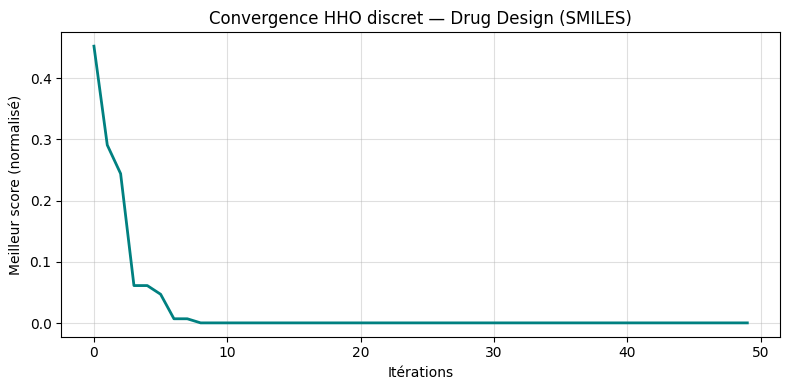

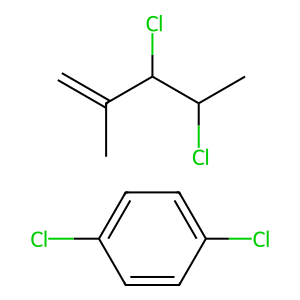

In [28]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors
from rdkit.Chem.rdchem import RWMol
from IPython.display import display


# ── Atom-level mutation (FIX 6: operates on Mol objects, not raw characters) ──

_ATOM_POOL = [6, 7, 8, 9, 16, 17]  # C N O F S Cl

def _try_canonicalize(mol) -> Optional[str]:
    """Return canonical SMILES if mol is valid, else None."""
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def atom_mutate(smiles: str, intensity: float) -> str:
    """
    Atom-level mutation: randomly swap atom types, add/remove atoms, or
    toggle bond orders on the RDKit Mol object.
    Returns canonical SMILES of the mutant, or the original if all attempts fail.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles

    n_atoms = mol.GetNumAtoms()
    n_muts = max(1, int(n_atoms * intensity))

    for _ in range(n_muts):
        action = random.choices(
            ['swap_atom', 'toggle_bond', 'add_atom', 'remove_atom'],
            weights=[0.45, 0.25, 0.20, 0.10]
        )[0]

        rw = RWMol(mol)
        n = rw.GetNumAtoms()
        if n == 0:
            break

        try:
            if action == 'swap_atom':
                idx = random.randint(0, n - 1)
                new_num = random.choice(_ATOM_POOL)
                rw.GetAtomWithIdx(idx).SetAtomicNum(new_num)

            elif action == 'toggle_bond' and rw.GetNumBonds() > 0:
                bond = random.choice(list(rw.GetBonds()))
                current = bond.GetBondTypeAsDouble()
                new_type = (
                    Chem.BondType.DOUBLE if current == 1.0
                    else Chem.BondType.SINGLE
                )
                rw.GetBondWithIdx(bond.GetIdx()).SetBondType(new_type)

            elif action == 'add_atom':
                new_idx = rw.AddAtom(Chem.Atom(random.choice(_ATOM_POOL)))
                anchor = random.randint(0, n - 1)
                rw.AddBond(anchor, new_idx, Chem.BondType.SINGLE)

            elif action == 'remove_atom' and n > 2:
                # Only remove terminal atoms (degree 1) to avoid disconnecting
                terminals = [a.GetIdx() for a in rw.GetAtoms() if a.GetDegree() == 1]
                if terminals:
                    rw.RemoveAtom(random.choice(terminals))

            candidate = _try_canonicalize(rw.GetMol())
            if candidate:
                mol = Chem.MolFromSmiles(candidate)  # update mol for next mutation

        except Exception:
            continue

    result = _try_canonicalize(mol)
    return result if result else smiles


def atom_crossover(smiles1: str, smiles2: str) -> str:
    """
    Fragment-aware crossover: cut both molecules at a random bond and
    swap fragments. Falls back to the original smiles1 if both fail.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        return smiles1

    for _ in range(8):
        try:
            # Pick a random bond in each molecule to cut
            bonds1 = list(mol1.GetBonds())
            bonds2 = list(mol2.GetBonds())
            if not bonds1 or not bonds2:
                break

            b1 = random.choice(bonds1)
            b2 = random.choice(bonds2)

            frag1 = Chem.FragmentOnBonds(mol1, [b1.GetIdx()], addDummies=False)
            frag2 = Chem.FragmentOnBonds(mol2, [b2.GetIdx()], addDummies=False)

            parts1 = Chem.GetMolFrags(frag1, asMols=True, sanitizeFrags=False)
            parts2 = Chem.GetMolFrags(frag2, asMols=True, sanitizeFrags=False)

            if not parts1 or not parts2:
                continue

            combined = Chem.CombineMols(parts1[0], parts2[-1])
            candidate = _try_canonicalize(combined)
            if candidate:
                return candidate
        except Exception:
            continue

    return smiles1


# ── FIX 5: Normalized fitness ──────────────────────────────────────────────

def smiles_fitness(smiles: str) -> float:
    """
    Normalized fitness: each term scaled to [0, 1] so they contribute equally.
      - MW target 300 Da  → normalized by 300
      - H-donors          → typical max ~5, normalized by 5
      - H-acceptors       → typical max ~10, normalized by 10
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return float('inf')
    mw = Descriptors.MolWt(mol)
    donors = Descriptors.NumHDonors(mol)
    acceptors = Descriptors.NumHAcceptors(mol)
    return abs(mw - 300) / 300.0 + donors / 5.0 + acceptors / 10.0


# ── Lévy-guided discrete jump (FIX 3: encodes the paper's rapid-dive idea) ──

def levy_jump(smiles: str, rabbit: str, E: float) -> str:
    """
    Discrete analogue of: Y = X_rabbit − E · |X_rabbit − X[i]| + L · Lévy()
    The Lévy scalar modulates mutation intensity and whether we start from
    rabbit or from self, mirroring the continuous paper equation.
    """
    L = levy_scalar()  # heavy-tailed step magnitude
    # Lévy scale → intensity in [0.05, 0.6] (clipped to avoid degenerate mutations)
    intensity = min(0.6, max(0.05, 0.1 * L))
    # abs(E) < 0.5 → exploit rabbit closely; abs(E) >= 0.5 → explore around rabbit
    if abs(E) < 0.5:
        return atom_mutate(rabbit, intensity)
    else:
        return atom_mutate(atom_crossover(smiles, rabbit), intensity)


# ── Corrected hho_discrete ─────────────────────────────────────────────────

def hho_discrete(
    obj_func: Callable[[str], float],
    initial_population: List[str],
    max_iter: int = 50
) -> Tuple[str, float, List[float]]:
    """
    Discrete HHO with all algorithmic fixes applied.

    Key changes vs original:
    - Exploration q<0.5: rabbit-energy guided perch (FIX 2)
    - Exploitation r<0.5: Lévy-driven rapid dive (FIX 3)
    - Greedy fallback: includes Lévy-jump candidate W (FIX 4)
    - Atom-level mutation instead of char-level (FIX 6)
    - Fitness uses normalized terms (FIX 5)
    - Rabbit updated inline each step (no one-iteration lag)
    """
    pop_size = len(initial_population)
    X = initial_population.copy()

    rabbit_location = ''
    rabbit_energy = float('inf')
    convergence_curve = []

    # Evaluate initial population once, cache scores
    fitness_vals = [obj_func(s) for s in X]
    for i, f in enumerate(fitness_vals):
        if f < rabbit_energy:
            rabbit_energy = f
            rabbit_location = X[i]

    for t in range(max_iter):
        print("iteration:", t)
        E1 = 2.0 * (1.0 - t / max_iter)

        for i in range(pop_size):
            # E0 ∈ (−1, 1) — confirmed correct range
            E0 = 2.0 * random.random() - 1.0
            E = E1 * E0
            fi = fitness_vals[i]

            if abs(E) >= 1.0:
                # ── Exploration phase ──────────────────────────────────────
                q = random.random()
                if q >= 0.5:
                    # Random tall-tree perch: crossover with a random hawk
                    rand_idx = random.randint(0, pop_size - 1)
                    candidate = atom_mutate(
                        atom_crossover(X[i], X[rand_idx]), intensity=0.3
                    )
                else:
                    # FIX 2: rabbit-energy perch — attracted toward prey region
                    # Paper: X(t+1) = X_rabbit − X_m + rand·(LB + rand·(UB-LB))
                    # Discrete: mutate a crossover between self and rabbit,
                    # scaled by a Lévy step for heavy-tailed exploration
                    L = levy_scalar()
                    intensity = min(0.6, max(0.05, 0.15 * L))
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=intensity
                    )

                fc = obj_func(candidate)
                if fc < fi:
                    X[i] = candidate
                    fitness_vals[i] = fc

            else:
                # ── Exploitation phase ─────────────────────────────────────
                r = random.random()

                if r >= 0.5 and abs(E) >= 0.5:
                    # Soft besiege
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=0.1
                    )
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r >= 0.5 and abs(E) < 0.5:
                    # Hard besiege
                    candidate = atom_mutate(rabbit_location, intensity=0.08)
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r < 0.5 and abs(E) >= 0.5:
                    # FIX 3+4: Soft besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)  # Lévy-guided candidate
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        # W term: another Lévy jump as fallback (paper's Z step)
                        W = levy_jump(rabbit_location, X[i], E)
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

                elif r < 0.5 and abs(E) < 0.5:
                    # FIX 3+4: Hard besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        W = atom_mutate(Y, intensity=0.2)  # local refinement
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

            # Inline rabbit update — no one-iteration lag
            if fitness_vals[i] < rabbit_energy:
                rabbit_energy = fitness_vals[i]
                rabbit_location = X[i]

        convergence_curve.append(rabbit_energy)

    return rabbit_location, rabbit_energy, convergence_curve


# ── Run Case 1 ─────────────────────────────────────────────────────────────
initial_smiles_pop = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",
    "C1=CC=CC=C1", "CC(C)C", "C=C", "CC#N", "C1CCCCC1",
    "C(C(=O)O)N", "c1cc(O)ccc1", "C1=CN=CN1", "C1=CC=NC=C1", "C1COCCO1",
    "CC1=CC=CC=C1", "CC(=O)C", "CC(O)C", "C1=CC=C(C=C1)O", "C1=CC=C(C=C1)N"
]

best_smiles, best_score, conv_curve_smiles = hho_discrete(
    obj_func=smiles_fitness,
    initial_population=initial_smiles_pop,
    max_iter=50
)

print("Meilleure molécule :", best_smiles)
mol = Chem.MolFromSmiles(best_smiles)
if mol:
    print(f"MW        : {Descriptors.MolWt(mol):.2f} Da")
    print(f"Donneurs H: {Descriptors.NumHDonors(mol)}")
    print(f"Accepteurs: {Descriptors.NumHAcceptors(mol)}")
print(f"Score normalisé : {best_score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(conv_curve_smiles, linewidth=2, color='teal')
plt.title('Convergence HHO discret — Drug Design (SMILES)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur score (normalisé)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

if mol:
    from rdkit.Chem import Draw
    display(Draw.MolToImage(mol))

# Cas 3 — RandomForest ML fitness avec HHO corrigé

Même algorithme HHO corrigé, avec `ml_smiles_fitness` comme fonction objectif.

**Fixes supplémentaires dans ce bloc :**
- Cache global (inclut les SMILES invalides)
- Normalization du score ML non nécessaire (pIC50 est déjà une échelle unique)
- Lévy flight intégré dans les branches d'exploitation

In [29]:
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display

print('Imports OK')

Imports OK


In [30]:
print("Chargement du modèle...")
full_pipeline = joblib.load('RandomForestRegressor_model/pIC50_prediction_pipeline.pkl')

variance_filter = full_pipeline.named_steps['filter']
lazy_regressor  = full_pipeline.named_steps['brain']
rf_model        = lazy_regressor.models['RandomForestRegressor']

input_feature_names    = list(variance_filter.feature_names_in_)
selected_feature_names = list(variance_filter.get_feature_names_out())

print(f"Features entrée     : {len(input_feature_names)}")
print(f"Features sélection. : {len(selected_feature_names)}")
print("Modèle chargé !")

Chargement du modèle...
Features entrée     : 2062
Features sélection. : 50
Modèle chargé !


In [31]:
# Global cache — persists across all iterations and runs
fitness_cache: dict = {}


def compute_lipinski_features(mol) -> list:
    """14 Lipinski-style descriptors."""
    mw    = Descriptors.MolWt(mol)
    logp  = Descriptors.MolLogP(mol)
    hdon  = Lipinski.NumHDonors(mol)
    hacc  = Lipinski.NumHAcceptors(mol)
    sa    = calculateScore(mol)
    qed   = QED.qed(mol)
    rb    = Descriptors.NumRotatableBonds(mol)
    ap    = Descriptors.FractionCSP3(mol)
    logs  = 0.16 - 0.63*logp - 0.0062*mw + 0.066*rb - 0.74*ap
    tpsa  = Descriptors.TPSA(mol)
    mvol  = rdMolDescriptors.CalcExactMolWt(mol)
    na    = mol.GetNumAtoms()
    nb_   = mol.GetNumBonds()
    arom  = rdMolDescriptors.CalcNumAromaticRings(mol) / na if na > 0 else 0
    return [mw, logp, hdon, hacc, sa, qed, rb, ap, logs, tpsa, mvol, na, nb_, arom]


def ml_smiles_fitness(smiles: str) -> float:
    """
    ML fitness via RandomForest pIC50 prediction.
    Returns -pIC50 (HHO minimises → we maximise pIC50).
    Cache includes invalid SMILES (FIX 7) to avoid repeated RDKit calls.
    """
    if smiles in fitness_cache:
        return fitness_cache[smiles]

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        fitness_cache[smiles] = 100.0
        return 100.0

    try:
        lipinski_vals  = compute_lipinski_features(mol)
        fps            = from_smiles(smiles, fingerprints=True)
        pubchem_vals   = [float(fps.get(f, 0.0)) for f in input_feature_names[14:]]
        X_full         = pd.DataFrame([lipinski_vals + pubchem_vals], columns=input_feature_names)
        X_filt         = pd.DataFrame(
            variance_filter.transform(X_full), columns=selected_feature_names
        )
        pIC50          = rf_model.predict(X_filt)[0]
        score          = -pIC50
        fitness_cache[smiles] = score
        return score
    except Exception as e:
        print(f"  [Erreur] {smiles}: {e}")
        fitness_cache[smiles] = 100.0
        return 100.0


# Quick test
test = 'c1ccccc1'
s    = ml_smiles_fitness(test)
print(f"Test {test} => pIC50 = {-s:.4f}")
print(f"Cache size: {len(fitness_cache)}")

Test c1ccccc1 => pIC50 = 4.0371
Cache size: 1


## Exécution

La fonction `hho_discrete` définie en Case 1 est réutilisée directement — elle est agnostique à la fonction objectif. Il suffit de passer `ml_smiles_fitness`.

HHO avec fitness ML (version corrigée)
iteration: 0


[17:18:28] non-ring atom 1 marked aromatic
[17:18:28] non-ring atom 2 marked aromatic
[17:18:28] non-ring atom 1 marked aromatic
[17:18:28] non-ring atom 1 marked aromatic
[17:18:28] non-ring atom 2 marked aromatic
[17:18:28] non-ring atom 2 marked aromatic
[17:18:28] non-ring atom 1 marked aromatic
[17:18:28] non-ring atom 1 marked aromatic
[17:18:32] non-ring atom 3 marked aromatic
[17:18:32] non-ring atom 3 marked aromatic
[17:18:32] non-ring atom 3 marked aromatic
[17:18:32] non-ring atom 3 marked aromatic
[17:18:32] non-ring atom 1 marked aromatic
[17:18:32] non-ring atom 2 marked aromatic
[17:18:32] non-ring atom 2 marked aromatic
[17:18:32] non-ring atom 3 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] non-ring atom 0 marked aromatic
[17:18:34] 

iteration: 1


[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] Can't kekulize mol.  Unkekulized atoms: 0 1 3 4 5
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] Explicit valence for atom # 1 Cl, 3, is greater than permitted
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:18:44] non-ring atom 0 marked aromatic
[17:1

iteration: 2
iteration: 3
iteration: 4


...

[17:23:30] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 6
[17:23:40] Can't kekulize mol.  Unkekulized atoms: 1 3 5 6 7
[17:23:40] Explicit valence for atom # 1 Cl, 4, is greater than permitted
[17:23:40] Can't kekulize mol.  Unkekulized atoms: 2 3 4 6 7


iteration: 13


[17:23:59] Explicit valence for atom # 1 O, 3, is greater than permitted
[17:24:04] Explicit valence for atom # 5 F, 3, is greater than permitted
[17:24:04] Can't kekulize mol.  Unkekulized atoms: 2 3 5 6 7
[17:24:04] Explicit valence for atom # 7 F, 4, is greater than permitted
[17:24:04] Can't kekulize mol.  Unkekulized atoms: 1 3 5 6 7


iteration: 14

Meilleure molécule : Nc1cc(Cl)ccc1Cl
Meilleur pIC50     : 4.1735
Entrées cache      : 81


[17:24:13] Can't kekulize mol.  Unkekulized atoms: 1 2 3 6 7
[17:24:13] Can't kekulize mol.  Unkekulized atoms: 1 2 3 5 6
[17:24:13] Explicit valence for atom # 8 Cl, 2, is greater than permitted
[17:24:13] Can't kekulize mol.  Unkekulized atoms: 1 2 5 6 7


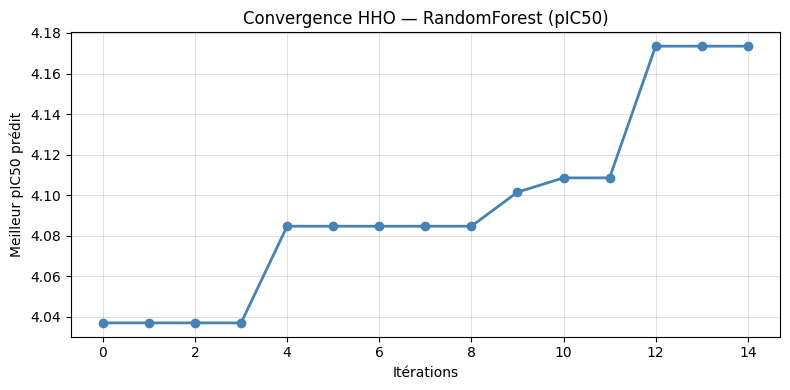

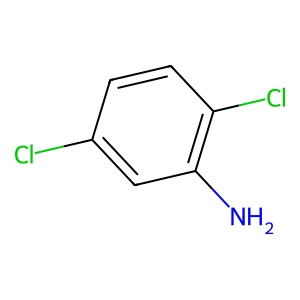

[17:24:14] non-ring atom 2 marked aromatic
[17:24:14] non-ring atom 1 marked aromatic
[17:24:14] non-ring atom 1 marked aromatic
[17:24:14] non-ring atom 1 marked aromatic
[17:24:14] non-ring atom 2 marked aromatic
[17:24:14] non-ring atom 2 marked aromatic
[17:24:14] non-ring atom 2 marked aromatic
[17:24:14] non-ring atom 2 marked aromatic


iteration: 0


[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 3 marked aromatic
[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 1 marked aromatic
[17:24:19] non-ring atom 2 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 0 marked aromatic
[17:24:27] non-ring atom 1 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] non-ring atom 3 marked aromatic
[17:24:27] 

iteration: 1


[17:24:34] non-ring atom 4 marked aromatic
[17:24:34] non-ring atom 1 marked aromatic
[17:24:34] non-ring atom 1 marked aromatic
[17:24:34] non-ring atom 1 marked aromatic
[17:24:34] non-ring atom 4 marked aromatic
[17:24:34] non-ring atom 1 marked aromatic
[17:24:34] non-ring atom 4 marked aromatic
[17:24:34] non-ring atom 1 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] non-ring atom 0 marked aromatic
[17:24:40] 

iteration: 2


KeyboardInterrupt: 

In [ ]:
print("=" * 60)
print("HHO avec fitness ML (version corrigée)")
print("=" * 60)

initial_pop_ml = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN"
]

# initial_pop_ml = [
#     # Original
#     "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",

#     # Alcohols / ethers
#     "CO", "CCCO", "CCOCC", "CC(C)O", "CC(C)(C)O",

#     # Carboxylic acids / esters
#     "C(=O)O", "CCC(=O)O", "CC(=O)OC", "CCOC(=O)C",

#     # Amines / amides
#     "CN", "CCCN", "CC(C)N", "CC(=O)N", "CNC(=O)C",

#     # Alkenes / alkynes
#     "C=CC", "CC=CC", "C#CC", "CC#N",

#     # Aromatics
#     "c1ccncc1", "c1ccccc1O", "c1ccccc1N", "c1ccccc1C(=O)O",

#     # Heterocycles
#     "C1CCOCC1", "C1=CC=CN=C1", "C1CCNCC1", "c1ccoc1",

#     # Halogenated compounds
#     "CCCl", "CCBr", "CF", "CC(F)F",

#     # Sulfur / phosphorus
#     "CS", "CCS", "CSP", "CC(=O)S",

#     # Slightly larger / branched
#     "CC(C)CC", "CCC(C)C", "CC(C)(C)C", "CCCCCC",

#     # Drug-like fragments
#     "CC1=CC=CC=C1", "CCOC1=CC=CC=C1", "CCN(CC)CC", "CCOC(=O)N"
# ]

best_ml, score_ml, curve_ml = hho_discrete(
    obj_func=ml_smiles_fitness,
    initial_population=initial_pop_ml,
    max_iter=15
)

print(f"\nMeilleure molécule : {best_ml}")
print(f"Meilleur pIC50     : {-score_ml:.4f}")
print(f"Entrées cache      : {len(fitness_cache)}")

plt.figure(figsize=(8, 4))
plt.plot([-s for s in curve_ml], linewidth=2, color='steelblue', marker='o')
plt.title('Convergence HHO — RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

mol_ml = Chem.MolFromSmiles(best_ml)
if mol_ml:
    display(Draw.MolToImage(mol_ml, size=(300, 300)))